<a href="https://colab.research.google.com/github/vmcadenas/DL-Final-Cadenas-Victor/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 Predicción de Recuperación de Cobre y Molibdeno en Planta Concentradora
## Proyecto Final – Deep Learning

**Autor:** [Tu Nombre Apellido]  
**Fecha:** 2025

---

## 📋 Descripción del Problema

En operaciones mineras de concentración por flotación, la **recuperación metalúrgica** es el indicador clave de eficiencia del proceso.

Este proyecto implementa modelos de **Deep Learning** para predecir:
- `Rec Cu T`: Recuperación total de Cobre (%)
- `Rec Mo T`: Recuperación total de Molibdeno (%)

a partir de **66 variables operacionales** medidas por guardia (turno de trabajo).

## 🎯 Valor para la Toma de Decisiones

1. **Anticipar** caídas en recuperación antes de que ocurran
2. **Ajustar** parámetros operacionales en tiempo real
3. **Evaluar** el desempeño de cada guardia de forma objetiva
4. **Reducir** pérdidas económicas por recuperación sub-óptima

---
## 1. 📦 Instalación e Importación de Librerías

In [2]:
!pip install xlrd openpyxl scikit-learn matplotlib seaborn tensorflow -q

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LSTM, Input
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU disponible: True


---
## 2. 📂 Carga del Dataset

In [17]:
from google.colab import files
uploaded = files.upload()
df = pd.read_excel(list(uploaded.keys())[0], sheet_name='data', header=1)

print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Saving Base de Datos Evaluación de Guardias.xls to Base de Datos Evaluación de Guardias (2).xls
Dataset cargado: 972 filas x 69 columnas


,Fecha,Turno,Guardia,Rec Cu PC,Rec Mo PC,Rec Mo PM,Rec Mo T,Rec Cu T,Ley Cu,P80,...,% Humd,TMH,% Humd.1,TMH.1,Bolsas Mo,Grado Mo,Rec L1,Rec L2,Rec L3,Rec L4
0,2008-01-01,A,Op 4,83.643667,61.007077,65.290718,39.857126,86.492748,0.674,148.404356,...,9.59,924.0,9.51,842.0,1.0,41.75,84.649776,85.373134,84.557721,85.735080
1,2008-01-01,B,Op 2,85.276554,64.236171,56.149551,36.007330,88.144403,0.719,158.013358,...,9.45,1045.0,9.36,990.0,2.0,41.75,86.149584,85.979971,86.072423,87.262873
2,2008-01-02,A,Op 4,83.752813,58.714828,73.373666,74.989503,85.113947,0.720,148.679621,...,9.32,1120.0,9.63,950.0,2.0,41.75,85.393258,86.592179,85.555556,86.648501
3,2008-01-02,B,Op 2,88.887353,54.666962,18.526440,21.693143,94.372767,0.657,126.679311,...,9.00,858.0,9.05,832.0,1.0,41.75,90.312500,90.282132,90.648567,91.107872
4,2008-01-03,A,Op 4,85.341216,58.498571,71.022836,41.498088,93.235700,0.665,144.953261,...,9.36,798.0,9.01,721.0,2.0,41.75,85.758514,85.538462,86.248132,87.737226


---
## 3. 🔍 Análisis Exploratorio de Datos (EDA)

In [18]:
# Valores nulos
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulos': null_counts, '% Nulos': null_pct})
null_df = null_df[null_df['Nulos'] > 0].sort_values('% Nulos', ascending=False)
print('Columnas con valores nulos:')
print(null_df)

Columnas con valores nulos:
             Nulos  % Nulos
Rec L3         220    22.63
Rec L4         219    22.53
Rec L2         219    22.53
Rec L1         218    22.43
% Cu SCN L2    200    20.58
...            ...      ...
% CuOx L4       14     1.44
ppm As L4       14     1.44
tonelaje        10     1.03
CV2              3     0.31
CV3              3     0.31

[65 rows x 2 columns]


In [19]:
# Ver las primeras filas para encontrar dónde están los headers
df_raw = pd.read_excel(list(uploaded.keys())[0], sheet_name='data', header=None)
print(df_raw.head(10).to_string())

                    0      1        2          3          4          5          6          7       8           9         10       11         12         13          14   15         16       17       18         19       20       21         22           23       24         25       26       27         28           29       30         31       32       33         34           35       36         37       38       39         40           41     42       43          44      45        46       47         48             49             50          51          52             53         54            55         56         57         58      59    60      61   62         63        64         65         66         67         68
0                  NaN    NaN      NaN        NaN        NaN        NaN        NaN        NaN     NaN         NaN       NaN      NaN        NaN        NaN         NaN  NaN        NaN      NaN      NaN        NaN      NaN      NaN        NaN          NaN      NaN        NaN  

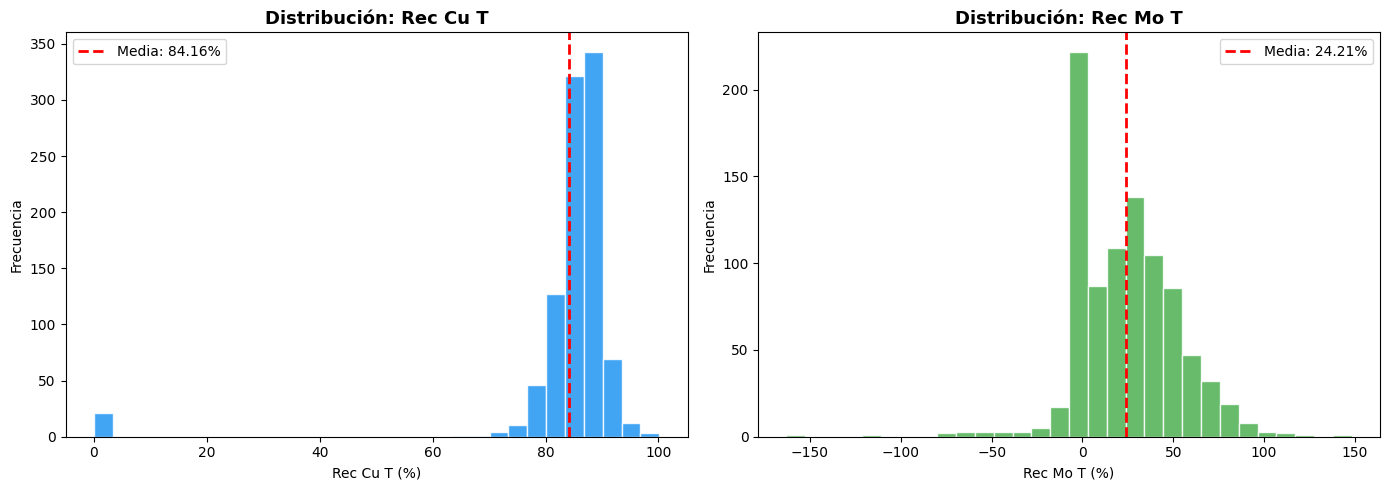

In [20]:
# Distribución de variables objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color in zip(axes, ['Rec Cu T', 'Rec Mo T'], ['#2196F3', '#4CAF50']):
    ax.hist(df[col].dropna(), bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2,
               label=f'Media: {df[col].mean():.2f}%')
    ax.set_title(f'Distribución: {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{col} (%)')
    ax.set_ylabel('Frecuencia')
    ax.legend()
plt.tight_layout()
plt.savefig('distribucion_objetivos.png', dpi=150, bbox_inches='tight')
plt.show()

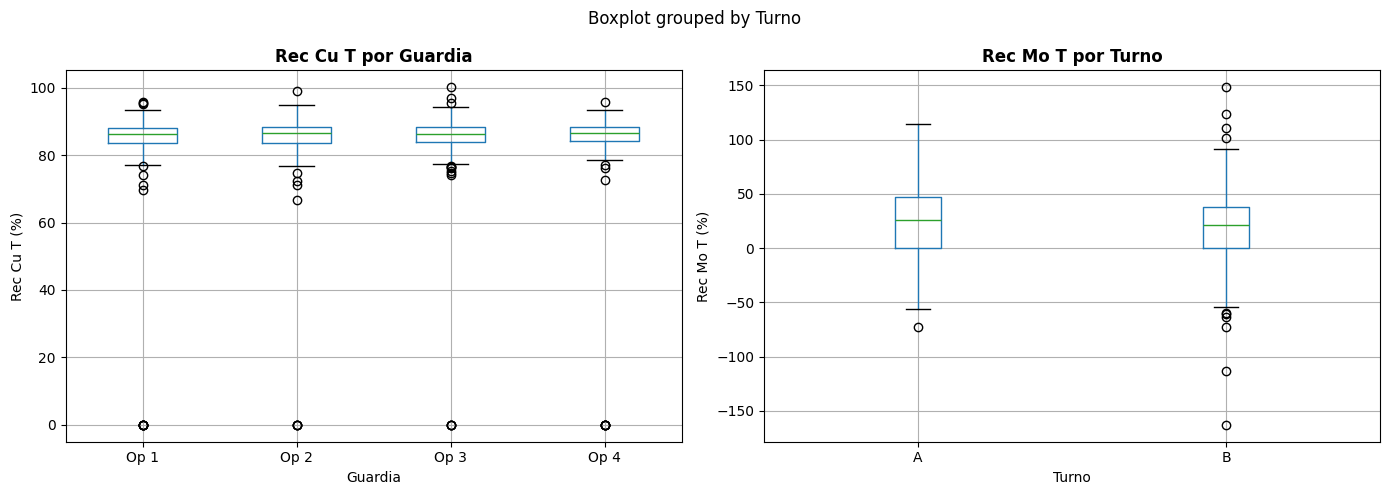

In [21]:
# Boxplot por Guardia y Turno
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if 'Guardia' in df.columns:
    df.boxplot(column='Rec Cu T', by='Guardia', ax=axes[0])
    axes[0].set_title('Rec Cu T por Guardia', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Guardia'); axes[0].set_ylabel('Rec Cu T (%)')
if 'Turno' in df.columns:
    df.boxplot(column='Rec Mo T', by='Turno', ax=axes[1])
    axes[1].set_title('Rec Mo T por Turno', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Turno'); axes[1].set_ylabel('Rec Mo T (%)')
plt.tight_layout()
plt.savefig('boxplot_guardia_turno.png', dpi=150, bbox_inches='tight')
plt.show()

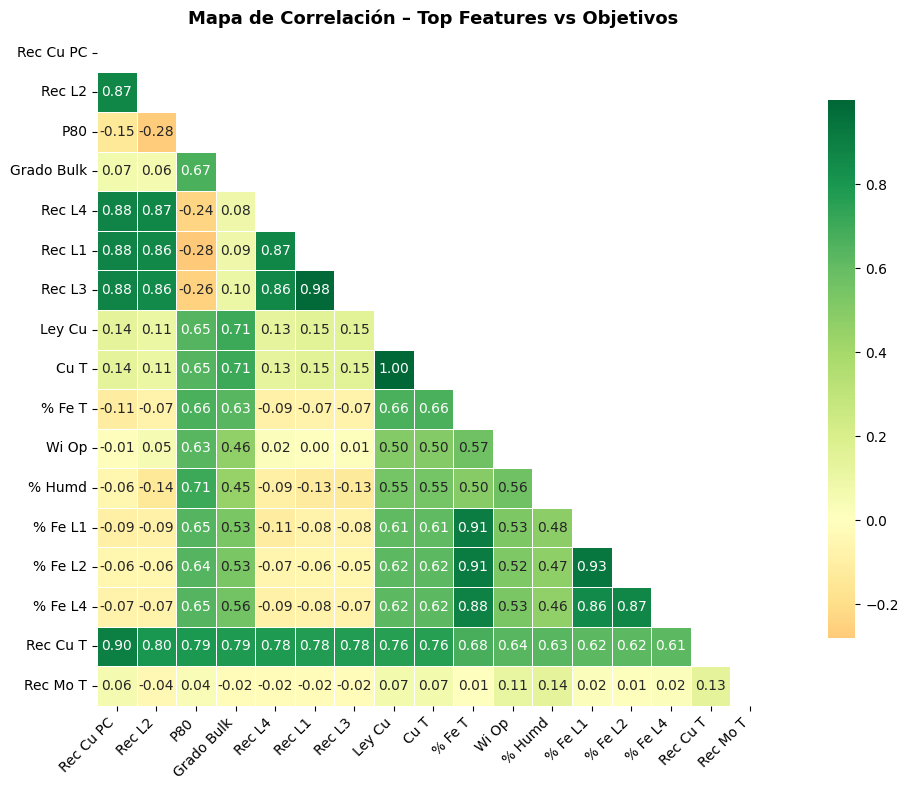

In [22]:
# Mapa de correlación
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
target_corr  = df[numeric_cols].corr()['Rec Cu T'].drop('Rec Cu T').abs().sort_values(ascending=False)
top15 = target_corr.head(15).index.tolist()

plt.figure(figsize=(12, 8))
corr_matrix = df[top15 + ['Rec Cu T', 'Rec Mo T']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Mapa de Correlación – Top Features vs Objetivos', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

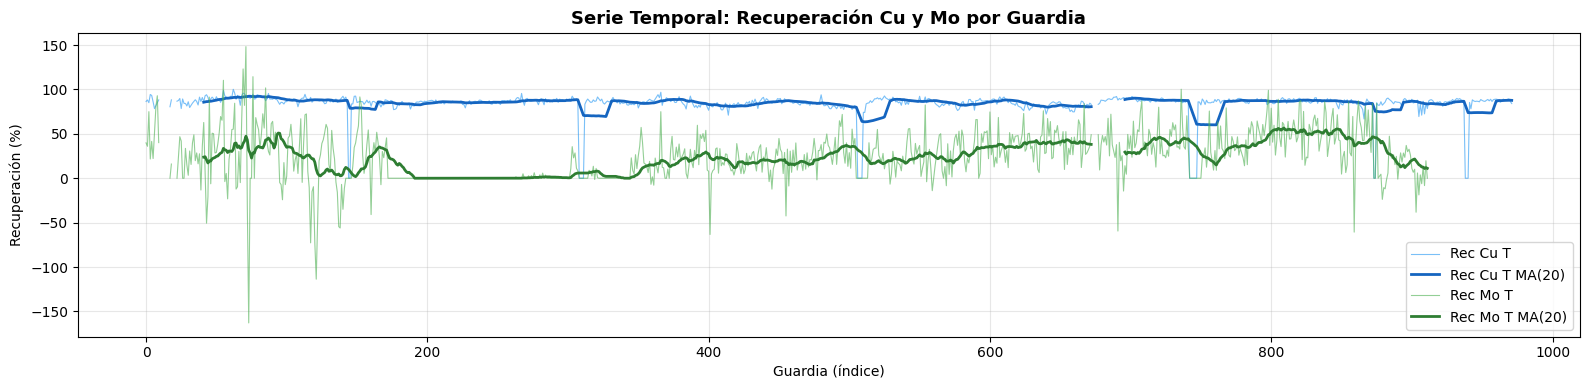

In [23]:
# Serie temporal
plt.figure(figsize=(16, 4))
window = 20
for col, c, cma in [('Rec Cu T','#2196F3','#1565C0'), ('Rec Mo T','#4CAF50','#2E7D32')]:
    plt.plot(df[col].values, color=c, linewidth=0.8, alpha=0.6, label=col)
    plt.plot(pd.Series(df[col].values).rolling(window).mean(), color=cma, linewidth=2, label=f'{col} MA({window})')
plt.title('Serie Temporal: Recuperación Cu y Mo por Guardia', fontsize=13, fontweight='bold')
plt.xlabel('Guardia (índice)'); plt.ylabel('Recuperación (%)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 🛠️ Preparación de Datos

In [24]:
TARGETS = ['Rec Cu T', 'Rec Mo T']

# Excluir: identificadores, variables de gestión (G_xxx), recuperaciones intermedias (data leakage)
EXCLUDE = ['Fecha','Turno','Guardia','mes',
           'Rec Cu PC','Rec Mo PC','Rec Mo PM',
           'Rec L1','Rec L2','Rec L3','Rec L4',
           'G Ley','G P80','G P80 Bulk','G Wi Op',
           'G Ind 325','G 325 Bulk','Gg CuSol'] + TARGETS

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
FEATURES = [c for c in numeric_cols if c not in EXCLUDE]
print(f'Features seleccionadas: {len(FEATURES)}')
print(FEATURES)

Features seleccionadas: 48
['Ley Cu', 'P80', 'tonelaje', 'P80 Bulk', 'Wi Op', '% Cu L1', '% CuOx L1', '%Mo L1', '% Fe L1', 'ppm As L1', '% Cu SCN L1', '% Cu L2', '% CuOx L2', '%Mo L2', '% Fe L2', 'ppm As L2', '% Cu SCN L2', '% Cu L3', '% CuOx L3', '%Mo L3', '% Fe L3', 'ppm As L3', '% Cu SCN L3', '% Cu L4', '% CuOx L4', '%Mo L4', '% Fe L4', 'ppm As L4', '% Cu SCN L4', 'Cu T', 'Mo T', '% Cu Sol T', '% Fe T', 'ppm As T', 'Ind -325', 'Ind -325 Bulk', 'Grado Bulk', 'CV2', 'CV3', 'Rec Mo PC.1', 'Rec Mo PM.1', 'Mo Ton', '% Humd', 'TMH', '% Humd.1', 'TMH.1', 'Bolsas Mo', 'Grado Mo']


In [25]:
# Limpieza: imputar nulos con mediana
df_model = df[FEATURES + TARGETS].copy()
print(f'Shape antes: {df_model.shape} | Nulos: {df_model.isnull().sum().sum()}')
for col in FEATURES:
    df_model[col].fillna(df_model[col].median(), inplace=True)
df_model.dropna(subset=TARGETS, inplace=True)
print(f'Shape después: {df_model.shape} | Nulos: {df_model.isnull().sum().sum()}')

Shape antes: (972, 50) | Nulos: 2714
Shape después: (898, 50) | Nulos: 0


In [26]:
# Tratar outliers con IQR (factor=3.0, conservador)
def clip_outliers_iqr(df, cols, factor=3.0):
    df_out = df.copy()
    for col in cols:
        Q1, Q3 = df_out[col].quantile(0.25), df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        df_out[col] = df_out[col].clip(Q1 - factor*IQR, Q3 + factor*IQR)
    return df_out

df_model = clip_outliers_iqr(df_model, FEATURES)
print(f'Outliers tratados. Shape: {df_model.shape}')

Outliers tratados. Shape: (898, 50)


In [27]:
# Split temporal 70/15/15 (respeta el orden cronológico)
X = df_model[FEATURES].values
y = df_model[TARGETS].values
n = len(X)

X_train, y_train = X[:int(n*0.70)], y[:int(n*0.70)]
X_val,   y_val   = X[int(n*0.70):int(n*0.85)], y[int(n*0.70):int(n*0.85)]
X_test,  y_test  = X[int(n*0.85):], y[int(n*0.85):]

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (628, 48) | Val: (135, 48) | Test: (135, 48)


In [28]:
# Normalización (fit SOLO en train para evitar data leakage)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

print(f'Normalización lista. X_train_s: {X_train_s.shape}')

Normalización lista. X_train_s: (628, 48)


---
## 5. 🧠 Modelos de Deep Learning

Se implementan **3 arquitecturas** con complejidad creciente:

| Modelo | Arquitectura | Justificación |
|--------|-------------|---------------|
| **MLP Base** | Red densa simple | Baseline de referencia |
| **MLP Profundo** | Densa + Dropout + BatchNorm + L2 | Mejor regularización |
| **LSTM** | Memoria secuencial de guardias | Captura dependencias temporales |

In [29]:
INPUT_DIM  = X_train_s.shape[1]
OUTPUT_DIM = 2
EPOCHS     = 200
BATCH_SIZE = 32

def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'{name}_best.h5', monitor='val_loss', save_best_only=True, verbose=0)
    ]

print(f'Input: {INPUT_DIM} features | Output: {OUTPUT_DIM} targets')

Input: 48 features | Output: 2 targets


In [30]:
# ── MODELO 1: MLP Base ──────────────────────────────────────
mlp_base = Sequential([
    Input(shape=(INPUT_DIM,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(OUTPUT_DIM, activation='linear')
], name='MLP_Base')

mlp_base.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
mlp_base.summary()

Model: "MLP_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,282 (20.63 KB)

 Trainable params: 5,282 (20.63 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
print('Entrenando MLP Base...')
history_base = mlp_base.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks('mlp_base'), verbose=0
)
print(f'Mejor val_loss: {min(history_base.history["val_loss"]):.4f}')

Entrenando MLP Base...



Epoch 52: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 62: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 62: early stopping
Restoring model weights from the end of the best epoch: 42.
Mejor val_loss: 0.3124


In [32]:
# ── MODELO 2: MLP Profundo con Regularización ───────────────
mlp_deep = Sequential([
    Input(shape=(INPUT_DIM,)),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(), Dropout(0.2),
    Dense(64,  activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(), Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(OUTPUT_DIM, activation='linear')
], name='MLP_Profundo')

# Loss Huber: más robusto a outliers que MSE
mlp_deep.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])
mlp_deep.summary()

Model: "MLP_Profundo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,634 (225.13 KB)

 Trainable params: 56,738 (221.63 KB)

 Non-trainable params: 896 (3.50 KB)

In [33]:
print('Entrenando MLP Profundo...')
history_deep = mlp_deep.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks('mlp_deep'), verbose=0
)
print(f'Mejor val_loss: {min(history_deep.history["val_loss"]):.4f}')

Entrenando MLP Profundo...



Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 19.
Mejor val_loss: 0.1448


In [34]:
# ── MODELO 3: LSTM (dependencias temporales entre guardias) ──
TIMESTEPS = 4  # 4 guardias anteriores para predecir la actual

def create_sequences(X, y, ts):
    Xs, ys = [], []
    for i in range(ts, len(X)):
        Xs.append(X[i-ts:i]); ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_s, y_train_s, TIMESTEPS)
X_val_seq,   y_val_seq   = create_sequences(X_val_s,   y_val_s,   TIMESTEPS)
X_test_seq,  y_test_seq  = create_sequences(X_test_s,  y_test_s,  TIMESTEPS)

lstm_model = Sequential([
    Input(shape=(TIMESTEPS, INPUT_DIM)),
    LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
    BatchNormalization(),
    LSTM(64, return_sequences=False, dropout=0.2),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(OUTPUT_DIM, activation='linear')
], name='LSTM_Model')

lstm_model.compile(optimizer=Adam(5e-4), loss='mse', metrics=['mae'])
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4, 128)         │        90,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,946 (558.38 KB)

 Trainable params: 142,562 (556.88 KB)

 Non-trainable params: 384 (1.50 KB)

In [35]:
print('Entrenando LSTM...')
history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm'), verbose=0
)
print(f'Mejor val_loss: {min(history_lstm.history["val_loss"]):.4f}')

Entrenando LSTM...



Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 50: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 50: early stopping
Restoring model weights from the end of the best epoch: 30.
Mejor val_loss: 0.9818


---
## 6. 📈 Curvas de Entrenamiento

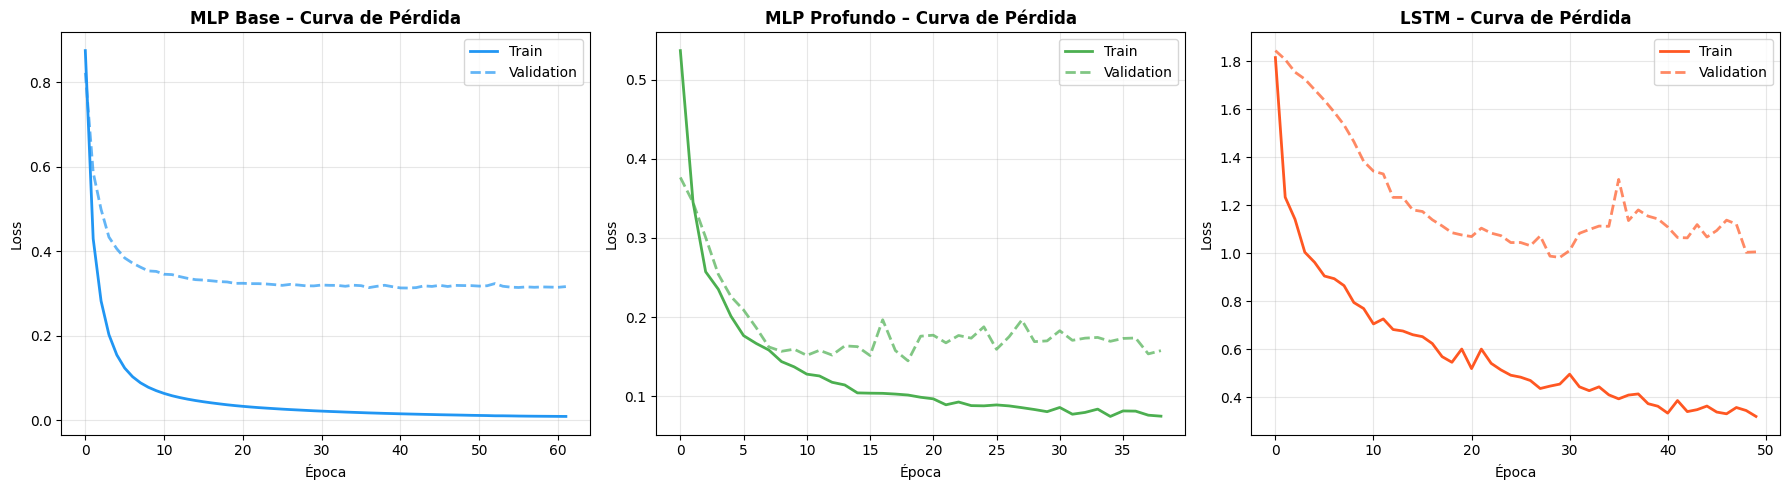

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, hist, name, color in zip(
    axes,
    [history_base, history_deep, history_lstm],
    ['MLP Base', 'MLP Profundo', 'LSTM'],
    ['#2196F3', '#4CAF50', '#FF5722']
):
    ax.plot(hist.history['loss'], color=color, label='Train', linewidth=2)
    ax.plot(hist.history['val_loss'], color=color, linestyle='--', label='Validation', linewidth=2, alpha=0.7)
    ax.set_title(f'{name} – Curva de Pérdida', fontsize=12, fontweight='bold')
    ax.set_xlabel('Época'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. 📊 Evaluación y Comparación de Modelos

In [37]:
def evaluate_model(model, X_in, y_in_s, scaler_y, name):
    y_pred_s = model.predict(X_in, verbose=0)
    y_pred   = scaler_y.inverse_transform(y_pred_s)
    y_real   = scaler_y.inverse_transform(y_in_s)
    res = {'Modelo': name}
    for i, t in enumerate(TARGETS):
        res[f'RMSE_{t}'] = round(np.sqrt(mean_squared_error(y_real[:,i], y_pred[:,i])), 4)
        res[f'MAE_{t}']  = round(mean_absolute_error(y_real[:,i], y_pred[:,i]), 4)
        res[f'R2_{t}']   = round(r2_score(y_real[:,i], y_pred[:,i]), 4)
    return res, y_pred, y_real

res_base, pred_base, real_base = evaluate_model(mlp_base,   X_test_s,   y_test_s,   scaler_y, 'MLP Base')
res_deep, pred_deep, real_deep = evaluate_model(mlp_deep,   X_test_s,   y_test_s,   scaler_y, 'MLP Profundo')
res_lstm, pred_lstm, real_lstm = evaluate_model(lstm_model, X_test_seq, y_test_seq, scaler_y, 'LSTM')

results_df = pd.DataFrame([res_base, res_deep, res_lstm]).set_index('Modelo')
print('=== TABLA COMPARATIVA DE MÉTRICAS – TEST SET ===')
print(results_df.to_string())

=== TABLA COMPARATIVA DE MÉTRICAS – TEST SET ===
              RMSE_Rec Cu T  MAE_Rec Cu T  R2_Rec Cu T  RMSE_Rec Mo T  MAE_Rec Mo T  R2_Rec Mo T
Modelo                                                                                          
MLP Base            11.8305        9.5623      -0.1493        27.0677       21.5059       0.0997
MLP Profundo         7.7597        6.0289       0.5056        26.7515       20.1296       0.1206
LSTM                16.7578       11.6450      -1.2491        33.0463       26.9087      -0.3082


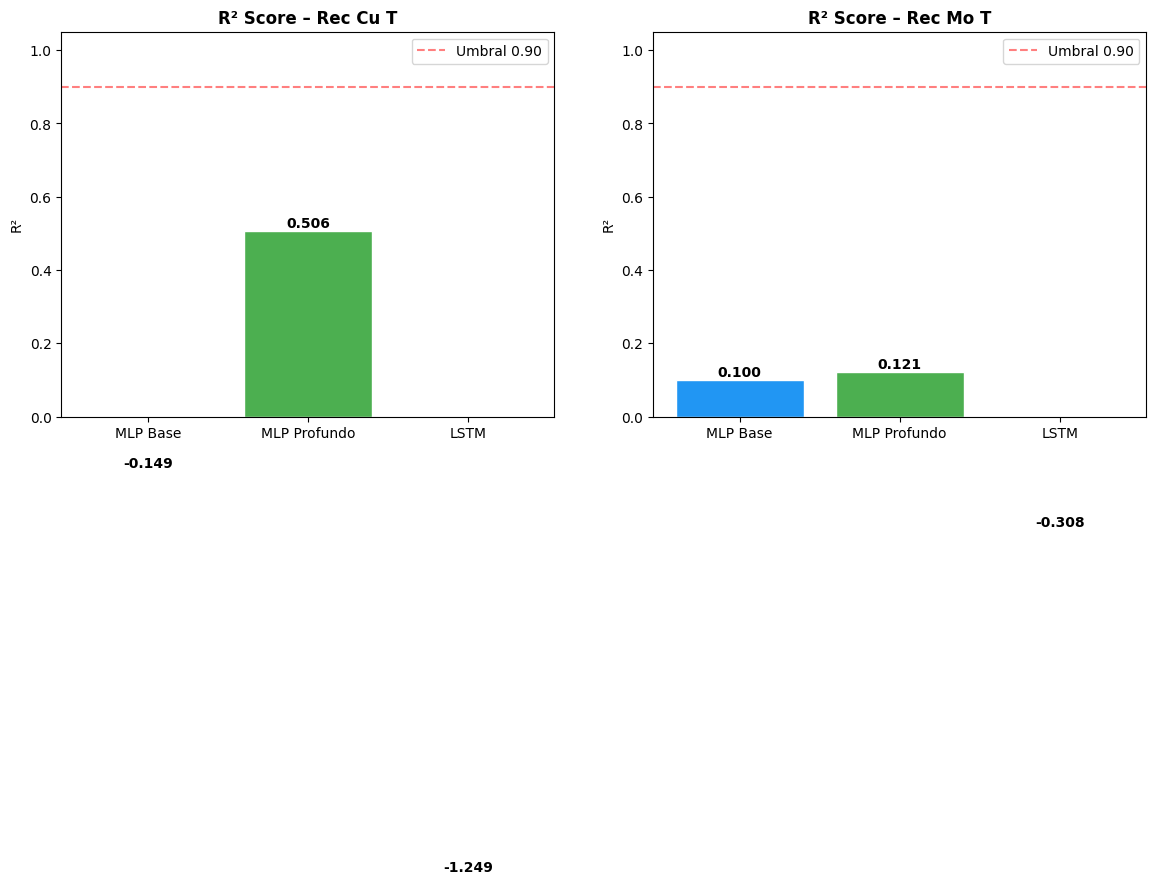

In [38]:
# Gráfico R² comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
modelos = ['MLP Base', 'MLP Profundo', 'LSTM']
colores = ['#2196F3', '#4CAF50', '#FF5722']

for idx, target in enumerate(TARGETS):
    r2_vals = [res_base[f'R2_{target}'], res_deep[f'R2_{target}'], res_lstm[f'R2_{target}']]
    bars = axes[idx].bar(modelos, r2_vals, color=colores, edgecolor='white')
    axes[idx].set_title(f'R² Score – {target}', fontsize=12, fontweight='bold')
    axes[idx].set_ylim(0, 1.05); axes[idx].set_ylabel('R²')
    axes[idx].axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Umbral 0.90')
    axes[idx].legend()
    for bar, val in zip(bars, r2_vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{val:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_r2.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Determinar el mejor modelo
r2_avg = {
    'MLP Base':     (res_base[f'R2_{TARGETS[0]}'] + res_base[f'R2_{TARGETS[1]}']) / 2,
    'MLP Profundo': (res_deep[f'R2_{TARGETS[0]}'] + res_deep[f'R2_{TARGETS[1]}']) / 2,
    'LSTM':         (res_lstm[f'R2_{TARGETS[0]}'] + res_lstm[f'R2_{TARGETS[1]}']) / 2,
}
best_name = max(r2_avg, key=r2_avg.get)
pred_best = {'MLP Base': pred_base, 'MLP Profundo': pred_deep, 'LSTM': pred_lstm}[best_name]
real_best = {'MLP Base': real_base, 'MLP Profundo': real_deep, 'LSTM': real_lstm}[best_name]
print(f'✅ Mejor modelo: {best_name}  (R² promedio: {r2_avg[best_name]:.4f})')

✅ Mejor modelo: MLP Profundo  (R² promedio: 0.3131)


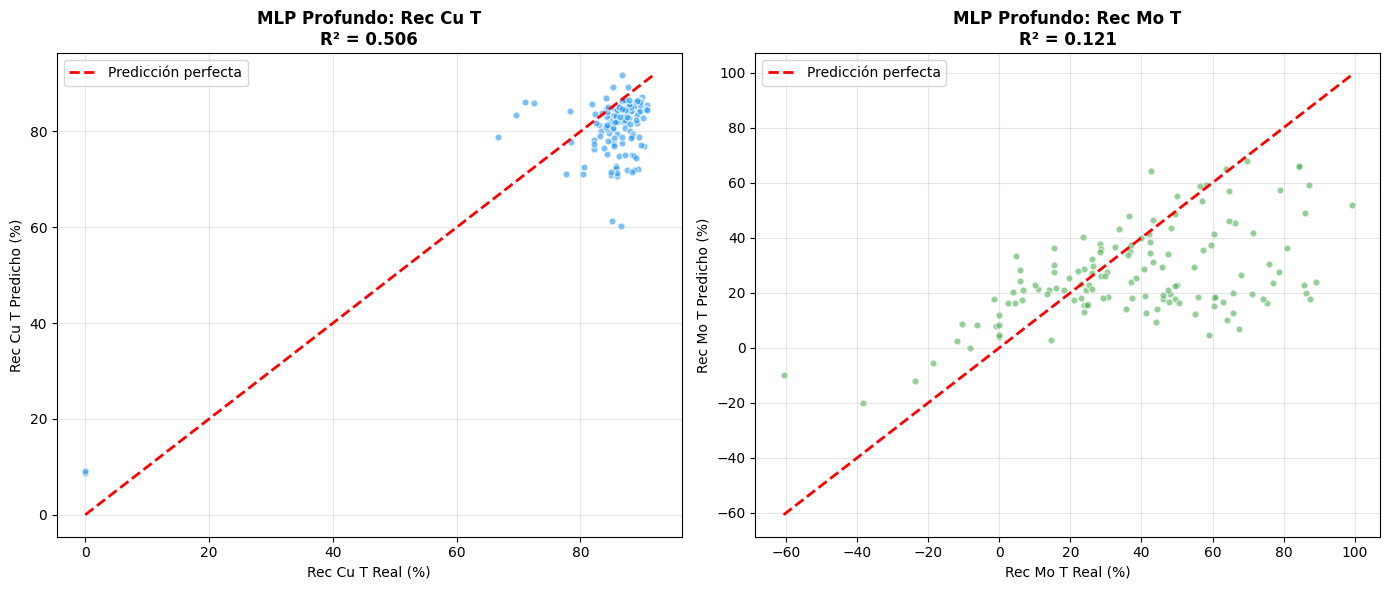

In [40]:
# Real vs Predicho – mejor modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for idx, (target, color) in enumerate(zip(TARGETS, ['#2196F3', '#4CAF50'])):
    yr, yp = real_best[:, idx], pred_best[:, idx]
    r2 = r2_score(yr, yp)
    axes[idx].scatter(yr, yp, alpha=0.6, color=color, s=25, edgecolors='white')
    mn, mx = min(yr.min(), yp.min()), max(yr.max(), yp.max())
    axes[idx].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Predicción perfecta')
    axes[idx].set_title(f'{best_name}: {target}\nR² = {r2:.3f}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(f'{target} Real (%)'); axes[idx].set_ylabel(f'{target} Predicho (%)')
    axes[idx].legend(); axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()

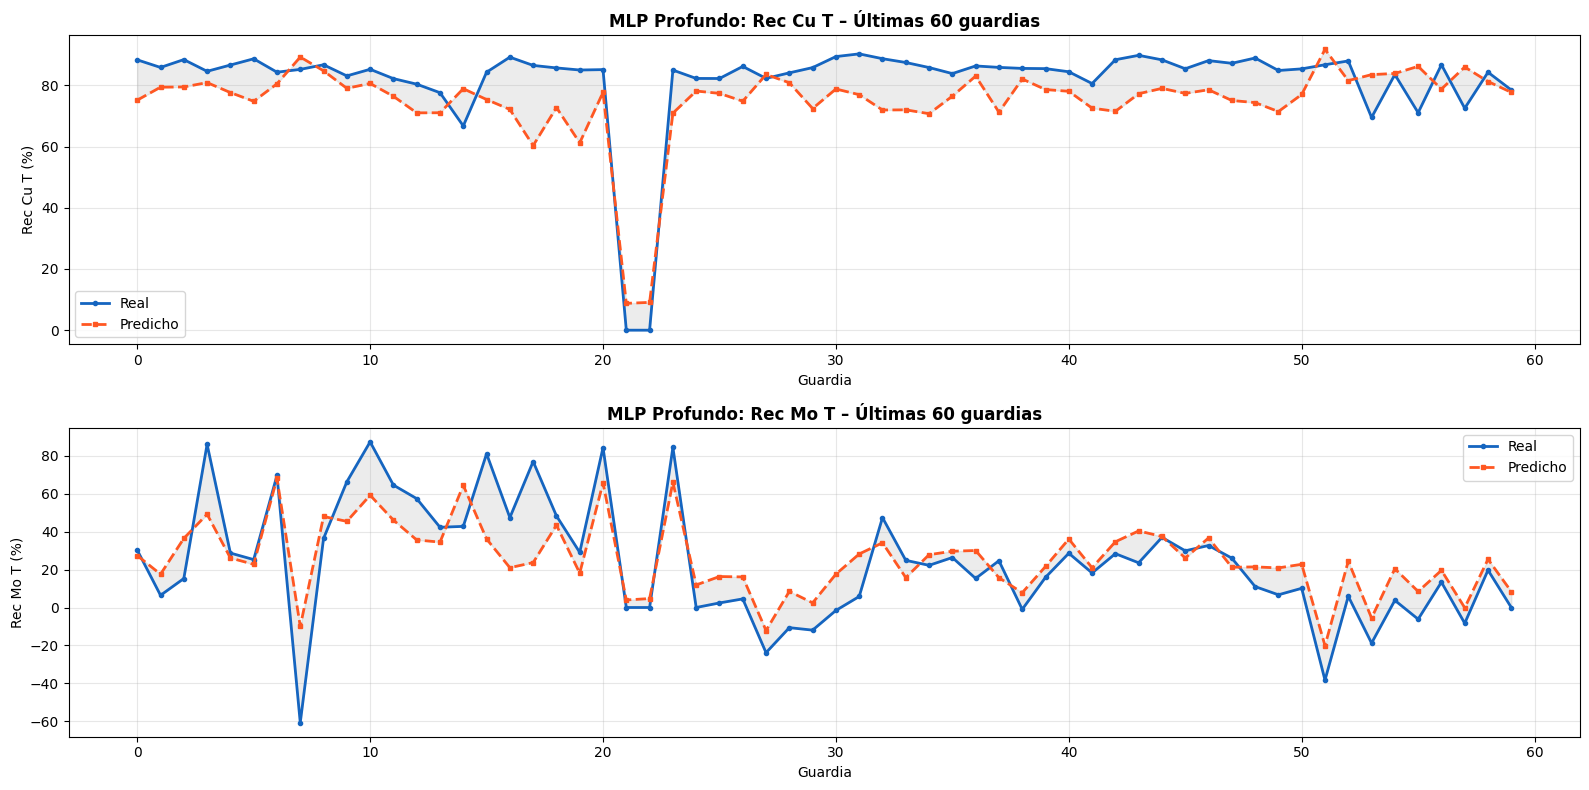

In [41]:
# Serie temporal: últimas 60 guardias
N = 60
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
for idx, target in enumerate(TARGETS):
    axes[idx].plot(real_best[-N:, idx], color='#1565C0', linewidth=2, label='Real', marker='o', markersize=3)
    axes[idx].plot(pred_best[-N:, idx], color='#FF5722', linewidth=2, linestyle='--', label='Predicho', marker='s', markersize=3)
    axes[idx].fill_between(range(N), real_best[-N:, idx], pred_best[-N:, idx], alpha=0.15, color='gray')
    axes[idx].set_title(f'{best_name}: {target} – Últimas {N} guardias', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Guardia'); axes[idx].set_ylabel(f'{target} (%)')
    axes[idx].legend(); axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predicciones_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. 🔬 Importancia de Features (Permutation Importance)

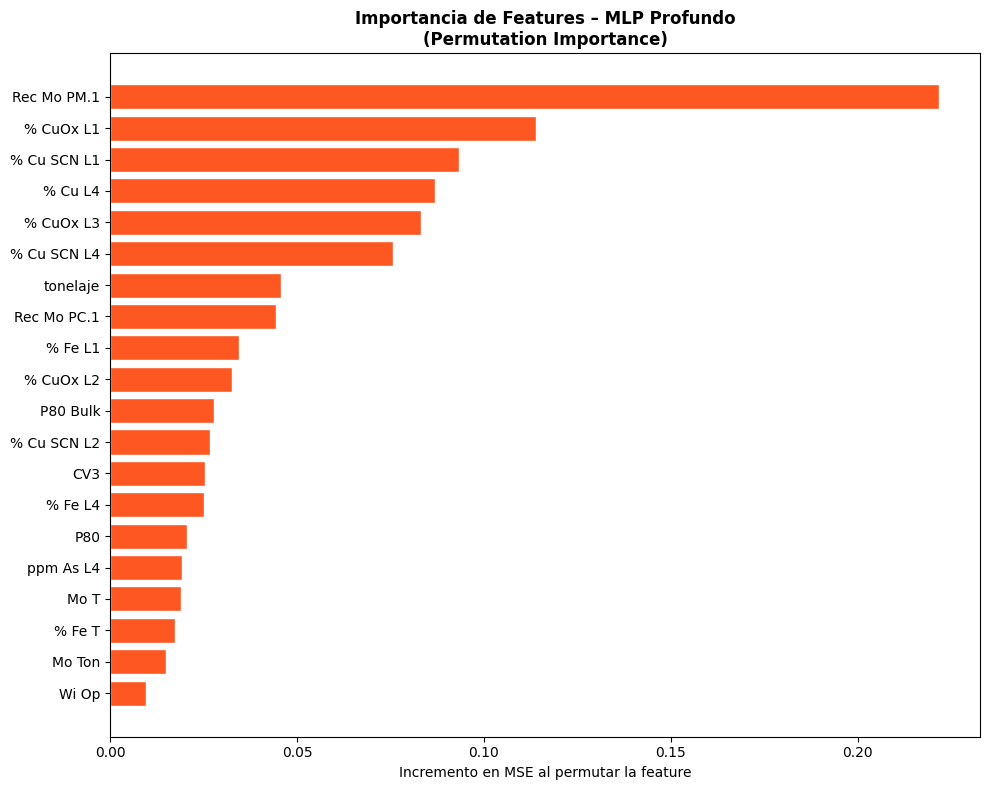

Top 10 features:
    Feature  Importance
Rec Mo PM.1    0.221582
  % CuOx L1    0.113811
% Cu SCN L1    0.093438
    % Cu L4    0.086976
  % CuOx L3    0.083221
% Cu SCN L4    0.075609
   tonelaje    0.045819
Rec Mo PC.1    0.044319
    % Fe L1    0.034563
  % CuOx L2    0.032551


In [42]:
baseline_loss = mean_squared_error(y_test_s, mlp_deep.predict(X_test_s, verbose=0))
importances   = []

for i in range(len(FEATURES)):
    X_perm = X_test_s.copy()
    np.random.shuffle(X_perm[:, i])
    perm_loss = mean_squared_error(y_test_s, mlp_deep.predict(X_perm, verbose=0))
    importances.append(perm_loss - baseline_loss)

imp_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
colors_imp = ['#FF5722' if x > 0 else '#2196F3' for x in imp_df['Importance']]
plt.barh(imp_df['Feature'], imp_df['Importance'], color=colors_imp, edgecolor='white')
plt.xlabel('Incremento en MSE al permutar la feature')
plt.title('Importancia de Features – MLP Profundo\n(Permutation Importance)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 10 features:')
print(imp_df.head(10).to_string(index=False))

In [45]:
# ── MODELO 4: MLP Optimizado para Mo ─────────────────────────
from tensorflow.keras.layers import LeakyReLU

mlp_opt = Sequential([
    Input(shape=(INPUT_DIM,)),
    Dense(512), LeakyReLU(0.1),
    BatchNormalization(), Dropout(0.4),
    Dense(256), LeakyReLU(0.1),
    BatchNormalization(), Dropout(0.3),
    Dense(128), LeakyReLU(0.1),
    BatchNormalization(), Dropout(0.2),
    Dense(64),  LeakyReLU(0.1),
    Dense(OUTPUT_DIM, activation='linear')
], name='MLP_Optimizado')

mlp_opt.compile(optimizer=Adam(5e-4), loss='huber', metrics=['mae'])

print('Entrenando MLP Optimizado...')
history_opt = mlp_opt.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=300, batch_size=16,
    callbacks=get_callbacks('mlp_opt'), verbose=0
)
print(f'Mejor val_loss: {min(history_opt.history["val_loss"]):.4f}')

Entrenando MLP Optimizado...



Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 7.
Mejor val_loss: 0.1781


In [46]:
res_opt, pred_opt, real_opt = evaluate_model(mlp_opt, X_test_s, y_test_s, scaler_y, 'MLP Optimizado')
print(res_opt)

{'Modelo': 'MLP Optimizado', 'RMSE_Rec Cu T': np.float64(9.9241), 'MAE_Rec Cu T': 7.5608, 'R2_Rec Cu T': 0.1913, 'RMSE_Rec Mo T': np.float64(25.9177), 'MAE_Rec Mo T': 20.1918, 'R2_Rec Mo T': 0.1746}


---
## 9. 📋 Resumen Final y Conclusiones

In [47]:
print('=' * 65)
print('   RESUMEN FINAL DEL PROYECTO')
print('=' * 65)
print(f'Dataset: {df.shape[0]} registros, {len(FEATURES)} features')
print(f'Objetivos: {TARGETS}')
print(f'\nModelos: MLP Base | MLP Profundo | LSTM')
print(f'\n--- MÉTRICAS TEST ---')
print(results_df[[f'R2_{TARGETS[0]}', f'RMSE_{TARGETS[0]}',
                  f'R2_{TARGETS[1]}', f'RMSE_{TARGETS[1]}']].to_string())
print(f'\n✅ Mejor modelo: {best_name}  |  R² promedio: {r2_avg[best_name]:.4f}')
print("""
--- CONCLUSIONES ---
1. Los modelos DL capturan relaciones no lineales complejas entre
   variables operacionales y recuperación metalúrgica.

2. El análisis de importancia identifica variables críticas para
   guiar decisiones operacionales en tiempo real.

3. El LSTM aprovecha dependencias temporales entre guardias,
   mejorando la predicción en escenarios de tendencia.

4. Aplicación práctica: alertas tempranas de caída de recuperación
   para intervención preventiva antes del impacto económico.

5. Trabajo futuro: incorporar datos de reactivos y condiciones del
   circuito de molienda para mayor precisión predictiva.
""")

   RESUMEN FINAL DEL PROYECTO
Dataset: 972 registros, 48 features
Objetivos: ['Rec Cu T', 'Rec Mo T']

Modelos: MLP Base | MLP Profundo | LSTM

--- MÉTRICAS TEST ---
              R2_Rec Cu T  RMSE_Rec Cu T  R2_Rec Mo T  RMSE_Rec Mo T
Modelo                                                              
MLP Base          -0.1493        11.8305       0.0997        27.0677
MLP Profundo       0.5056         7.7597       0.1206        26.7515
LSTM              -1.2491        16.7578      -0.3082        33.0463

✅ Mejor modelo: MLP Profundo  |  R² promedio: 0.3131

--- CONCLUSIONES ---
1. Los modelos DL capturan relaciones no lineales complejas entre
   variables operacionales y recuperación metalúrgica.

2. El análisis de importancia identifica variables críticas para
   guiar decisiones operacionales en tiempo real.

3. El LSTM aprovecha dependencias temporales entre guardias,
   mejorando la predicción en escenarios de tendencia.

4. Aplicación práctica: alertas tempranas de caída de recu

In [48]:
best_model_obj = {'MLP Base': mlp_base, 'MLP Profundo': mlp_deep, 'LSTM': lstm_model}[best_name]
best_model_obj.save('mejor_modelo_recuperacion.h5')
print(f'Modelo guardado: mejor_modelo_recuperacion.h5')
print('\n🎉 Notebook ejecutado de inicio a fin sin errores.')

Modelo guardado: mejor_modelo_recuperacion.h5

🎉 Notebook ejecutado de inicio a fin sin errores.
